# Result Analysis: Performance Change by Experiment Settings

This notebook analyzes `output/summary/kfold_summary_experiment_means.csv` and visualizes how performance changes with setting changes (`experiment`, `conn_num`, `loss`, `num_folds`).


In [21]:
from pathlib import Path
import autorootcwd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.options.display.float_format = '{:.4f}'.format

# Priority: split summaries (5fold/1fold) first, then combined summary.
csv_candidates = [
    Path('output/summary/kfold_summary_experiment_means_1fold.csv'),
]

CSV_PATH = None
for candidate in csv_candidates:
    if candidate.exists():
        CSV_PATH = candidate
        break
if CSV_PATH is None:
    raise FileNotFoundError('Could not find kfold_summary_experiment_means*.csv from current working directory.')

FIG_DIR = CSV_PATH.parent / 'analysis_figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

metrics = ['best_dice_mean', 'best_jac_mean', 'best_cldice_mean']
metric_labels = {
    'best_dice_mean': 'Dice',
    'best_jac_mean': 'Jac',
    'best_cldice_mean': 'clDice',
}

df = pd.read_csv(CSV_PATH)
df['experiment_loss'] = df['experiment'] + ' | ' + df['loss']
df['config'] = (
    df['experiment']
    + '|' + df['loss']
    + '|conn' + df['conn_num'].astype(str)
    + '|fold' + df['num_folds'].astype(str)
)

df = df.sort_values(['experiment', 'loss', 'conn_num', 'num_folds']).reset_index(drop=True)
print(f'Loaded {CSV_PATH} with {len(df)} rows')
df

Loaded output/summary/kfold_summary_experiment_means_1fold.csv with 10 rows


,experiment,conn_num,loss,num_folds,best_dice_mean,best_jac_mean,best_cldice_mean,experiment_loss,config
0,binary,8,bce,1,0.8100,0.6686,0.8415,binary | bce,binary|bce|conn8|fold1
1,binary,24,bce,1,0.8136,0.6788,0.8430,binary | bce,binary|bce|conn24|fold1
2,dist_inverted,8,gjml_sf_l1,1,0.8222,0.6901,0.8561,dist_inverted | gjml_sf_l1,dist_inverted|gjml_sf_l1|conn8|fold1
3,dist_inverted,24,gjml_sf_l1,1,0.8208,0.6917,0.8592,dist_inverted | gjml_sf_l1,dist_inverted|gjml_sf_l1|conn24|fold1
4,dist_inverted,8,smooth_l1,1,0.8230,0.6774,0.8606,dist_inverted | smooth_l1,dist_inverted|smooth_l1|conn8|fold1
5,dist_inverted,24,smooth_l1,1,0.8232,0.6738,0.8676,dist_inverted | smooth_l1,dist_inverted|smooth_l1|conn24|fold1
6,dist,8,gjml_sf_l1,1,0.8240,0.6920,0.8516,dist | gjml_sf_l1,dist|gjml_sf_l1|conn8|fold1
7,dist,24,gjml_sf_l1,1,0.8221,0.6865,0.8396,dist | gjml_sf_l1,dist|gjml_sf_l1|conn24|fold1
8,dist,8,smooth_l1,1,0.8228,0.6923,0.8592,dist | smooth_l1,dist|smooth_l1|conn8|fold1
9,dist,24,smooth_l1,1,0.8139,0.6635,0.8419,dist | smooth_l1,dist|smooth_l1|conn24|fold1


## 1) Absolute performance by full config

Each bar is one full configuration (`experiment|loss|conn|fold`). Blue = 5 folds, orange = 1 fold.


Saved: output/summary/analysis_figures/abs_performance_by_config.png


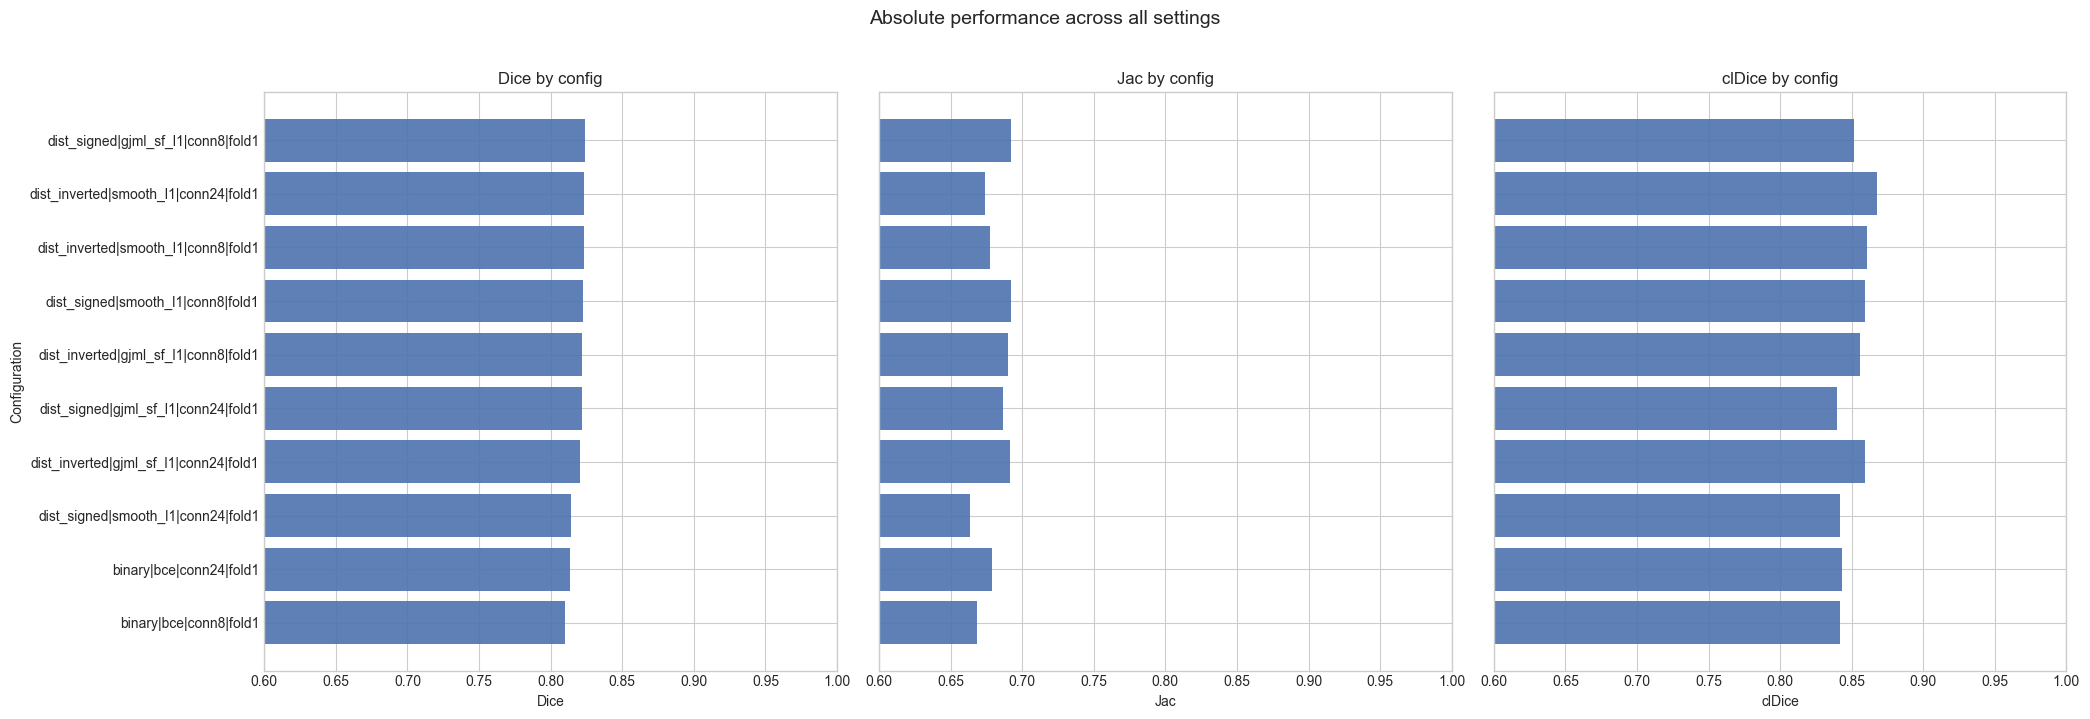

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7), sharey=True)

for ax, metric in zip(axes, metrics):
    plot_df = df.sort_values(metric, ascending=True).copy()
    ax.barh(plot_df['config'], plot_df[metric], color='#4c72b0', alpha=0.9)
    ax.set_title(f'{metric_labels[metric]} by config')
    ax.set_xlabel(metric_labels[metric])
    ax.set_xlim(0.6, 1.0)

axes[0].set_ylabel('Configuration')
fig.suptitle('Absolute performance across all settings', y=1.02, fontsize=14)
plt.tight_layout()

out_path = FIG_DIR / 'abs_performance_by_config.png'
fig.savefig(out_path, dpi=170, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()

## 2) Experiment-wise comparison

Compares `binary`, `dist`, and `dist_inverted` by aggregating over other settings.


Saved: output/summary/analysis_figures/experiment_comparison_mean_vs_best.png


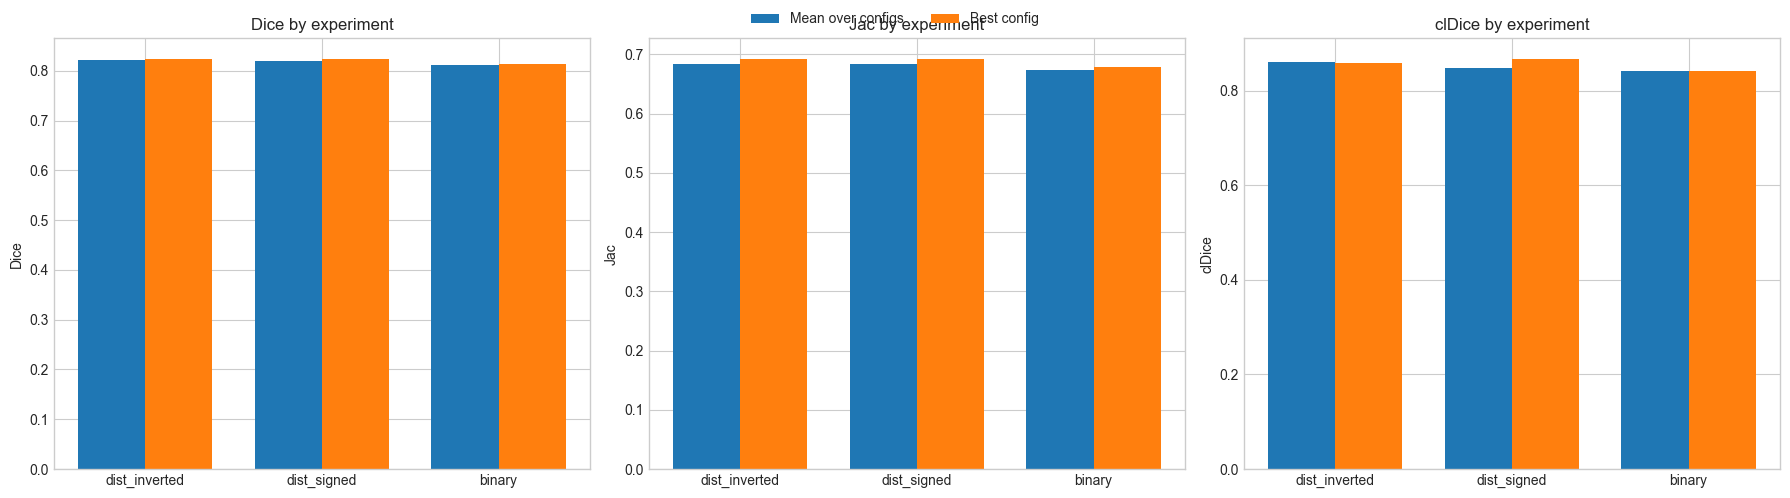

Experiment mean metrics:
   experiment  best_dice_mean  best_jac_mean  best_cldice_mean
dist_inverted          0.8223         0.6833            0.8609
  dist          0.8207         0.6836            0.8481
       binary          0.8118         0.6737            0.8422

Experiment best metrics:
   experiment  best_dice_mean  best_jac_mean  best_cldice_mean
  dist          0.8240         0.6923            0.8592
dist_inverted          0.8232         0.6917            0.8676
       binary          0.8136         0.6788            0.8430


In [23]:
exp_mean = df.groupby('experiment', as_index=False)[metrics].mean().sort_values('best_dice_mean', ascending=False)
exp_max = df.groupby('experiment', as_index=False)[metrics].max().sort_values('best_dice_mean', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
for ax, metric in zip(axes, metrics):
    x = np.arange(len(exp_mean))
    w = 0.38
    ax.bar(x - w/2, exp_mean[metric], width=w, color='#1f77b4', label='Mean over configs')
    ax.bar(x + w/2, exp_max[metric], width=w, color='#ff7f0e', label='Best config')
    ax.set_xticks(x)
    ax.set_xticklabels(exp_mean['experiment'])
    ax.set_title(f'{metric_labels[metric]} by experiment')
    ax.set_ylabel(metric_labels[metric])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)
plt.tight_layout()

out_path = FIG_DIR / 'experiment_comparison_mean_vs_best.png'
fig.savefig(out_path, dpi=170, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()

print('Experiment mean metrics:')
print(exp_mean.to_string(index=False))
print('\nExperiment best metrics:')
print(exp_max.to_string(index=False))

## 3) Effect of connectivity size (`24 - 8`)

Positive bar means `conn_num=24` performed better than `conn_num=8` for the same `experiment/loss/num_folds`.


Saved: output/summary/analysis_figures/delta_conn_24_minus_8.png


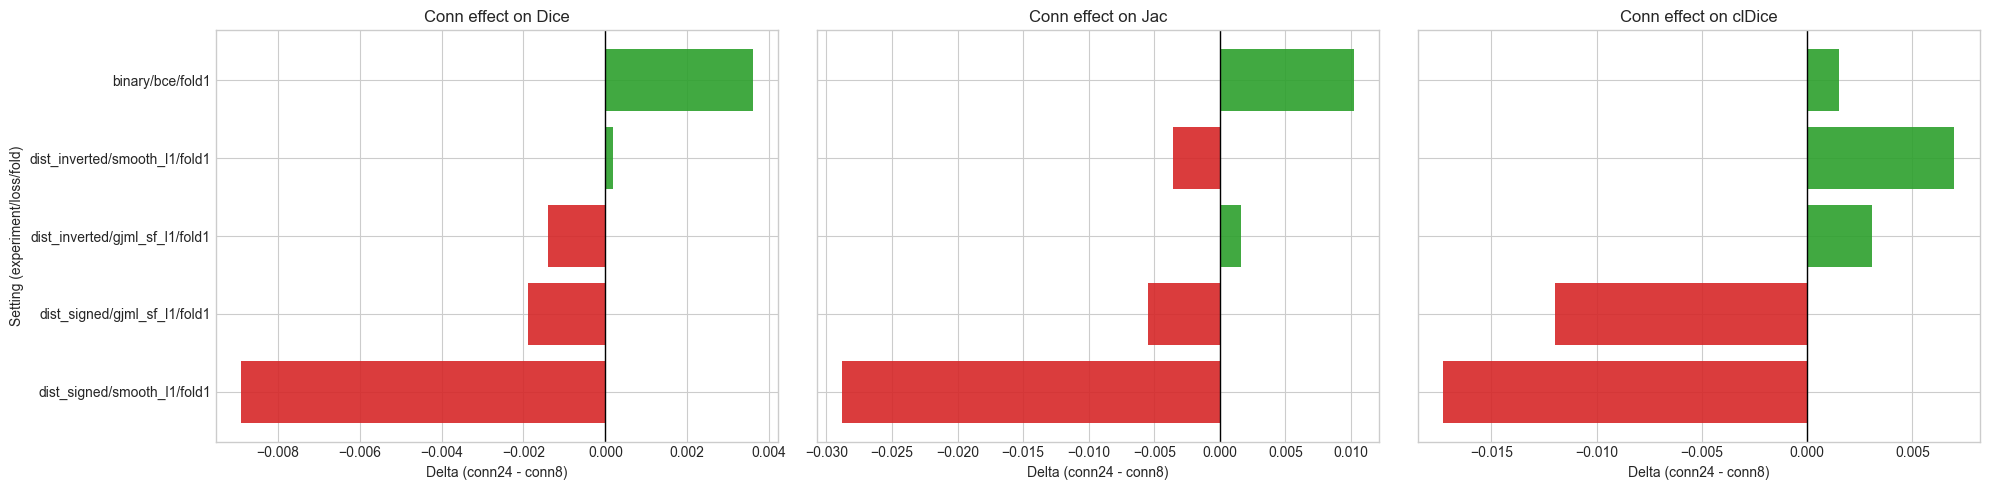

,setting,best_dice_mean,best_jac_mean,best_cldice_mean
0,binary/bce/fold1,0.0036,0.0102,0.0015
2,dist_inverted/smooth_l1/fold1,0.0002,-0.0036,0.0070
1,dist_inverted/gjml_sf_l1/fold1,-0.0014,0.0016,0.0031
3,dist/gjml_sf_l1/fold1,-0.0019,-0.0055,-0.0120
4,dist/smooth_l1/fold1,-0.0089,-0.0288,-0.0173


In [24]:
conn_pivot = df.pivot_table(index=['experiment', 'loss', 'num_folds'], columns='conn_num', values=metrics)

conn_delta = pd.DataFrame(index=conn_pivot.index)
for metric in metrics:
    conn_delta[metric] = conn_pivot[(metric, 24)] - conn_pivot[(metric, 8)]

conn_delta = conn_delta.reset_index()
conn_delta['setting'] = (
    conn_delta['experiment']
    + '/' + conn_delta['loss']
    + '/fold' + conn_delta['num_folds'].astype(str)
)

fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)
for ax, metric in zip(axes, metrics):
    d = conn_delta.sort_values(metric, ascending=True)
    colors = np.where(d[metric] >= 0, '#2ca02c', '#d62728')
    ax.barh(d['setting'], d[metric], color=colors, alpha=0.9)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_title(f'Conn effect on {metric_labels[metric]}')
    ax.set_xlabel('Delta (conn24 - conn8)')

axes[0].set_ylabel('Setting (experiment/loss/fold)')
plt.tight_layout()

out_path = FIG_DIR / 'delta_conn_24_minus_8.png'
fig.savefig(out_path, dpi=170, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()

conn_delta[['setting'] + metrics].sort_values('best_dice_mean', ascending=False)

## 4) Effect of dist auxiliary loss (`gjml_sf_l1 - smooth_l1`)

This comparison applies only to dist experiments (`dist`, `dist_inverted`).


Saved: output/summary/analysis_figures/delta_loss_gjml_minus_smooth.png


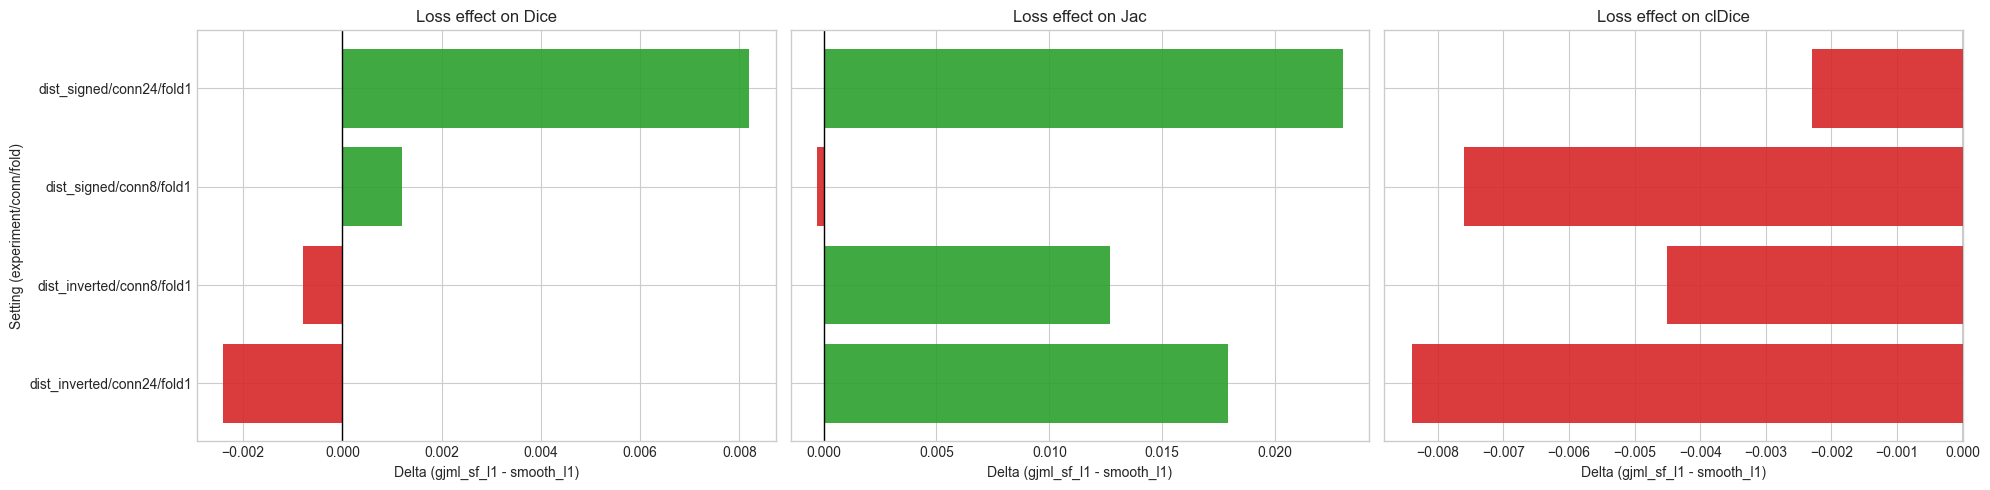

,setting,best_dice_mean,best_jac_mean,best_cldice_mean
3,dist/conn24/fold1,0.0082,0.0230,-0.0023
2,dist/conn8/fold1,0.0012,-0.0003,-0.0076
0,dist_inverted/conn8/fold1,-0.0008,0.0127,-0.0045
1,dist_inverted/conn24/fold1,-0.0024,0.0179,-0.0084


In [25]:
dist_df = df[df['experiment'] != 'binary'].copy()
loss_pivot = dist_df.pivot_table(index=['experiment', 'conn_num', 'num_folds'], columns='loss', values=metrics)

loss_delta = pd.DataFrame(index=loss_pivot.index)
for metric in metrics:
    loss_delta[metric] = loss_pivot[(metric, 'gjml_sf_l1')] - loss_pivot[(metric, 'smooth_l1')]

loss_delta = loss_delta.reset_index()
loss_delta['setting'] = (
    loss_delta['experiment']
    + '/conn' + loss_delta['conn_num'].astype(str)
    + '/fold' + loss_delta['num_folds'].astype(str)
)

fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)
for ax, metric in zip(axes, metrics):
    d = loss_delta.sort_values(metric, ascending=True)
    colors = np.where(d[metric] >= 0, '#2ca02c', '#d62728')
    ax.barh(d['setting'], d[metric], color=colors, alpha=0.9)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_title(f'Loss effect on {metric_labels[metric]}')
    ax.set_xlabel('Delta (gjml_sf_l1 - smooth_l1)')

axes[0].set_ylabel('Setting (experiment/conn/fold)')
plt.tight_layout()

out_path = FIG_DIR / 'delta_loss_gjml_minus_smooth.png'
fig.savefig(out_path, dpi=170, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()

loss_delta[['setting'] + metrics].sort_values('best_dice_mean', ascending=False)

## 5) Compact numeric summary

This cell prints best settings and average deltas to make trend reading easier.


In [26]:
summary_rows = []
for metric in metrics:
    best_idx = df[metric].idxmax()
    summary_rows.append({
        'metric': metric_labels[metric],
        'experiment': df.loc[best_idx, 'experiment'],
        'loss': df.loc[best_idx, 'loss'],
        'conn_num': int(df.loc[best_idx, 'conn_num']),
        'num_folds': int(df.loc[best_idx, 'num_folds']),
        'best_value': float(df.loc[best_idx, metric]),
    })

best_table = pd.DataFrame(summary_rows)
experiment_mean_rank = df.groupby('experiment', as_index=False)[metrics].mean().sort_values('best_dice_mean', ascending=False)

delta_overview = pd.DataFrame({
    'metric': [metric_labels[m] for m in metrics],
    'mean_delta_conn_24_minus_8': [conn_delta[m].mean() for m in metrics],
    'mean_delta_loss_gjml_minus_smooth': [loss_delta[m].mean() for m in metrics],
})

print('Best config per metric:')
print(best_table.to_string(index=False))
print('\nExperiment mean ranking:')
print(experiment_mean_rank.to_string(index=False))
print('\nAverage delta overview:')
print(delta_overview.to_string(index=False))

Best config per metric:
metric    experiment       loss  conn_num  num_folds  best_value
  Dice   dist gjml_sf_l1         8          1      0.8240
   Jac   dist  smooth_l1         8          1      0.6923
clDice dist_inverted  smooth_l1        24          1      0.8676

Experiment mean ranking:
   experiment  best_dice_mean  best_jac_mean  best_cldice_mean
dist_inverted          0.8223         0.6833            0.8609
  dist          0.8207         0.6836            0.8481
       binary          0.8118         0.6737            0.8422

Average delta overview:
metric  mean_delta_conn_24_minus_8  mean_delta_loss_gjml_minus_smooth
  Dice                     -0.0017                             0.0016
   Jac                     -0.0052                             0.0133
clDice                     -0.0035                            -0.0057
